--- Exploratory Data Analysis (EDA) ---

📊 Distribusi untuk TRAIN:
  - real: 50,000 gambar
  - fake: 50,000 gambar
  Total train: 100,000 gambar

📊 Distribusi untuk VALID:
  - real: 10,000 gambar
  - fake: 10,000 gambar
  Total valid: 20,000 gambar

📊 Distribusi untuk TEST:
  - real: 10,000 gambar
  - fake: 10,000 gambar
  Total test: 20,000 gambar


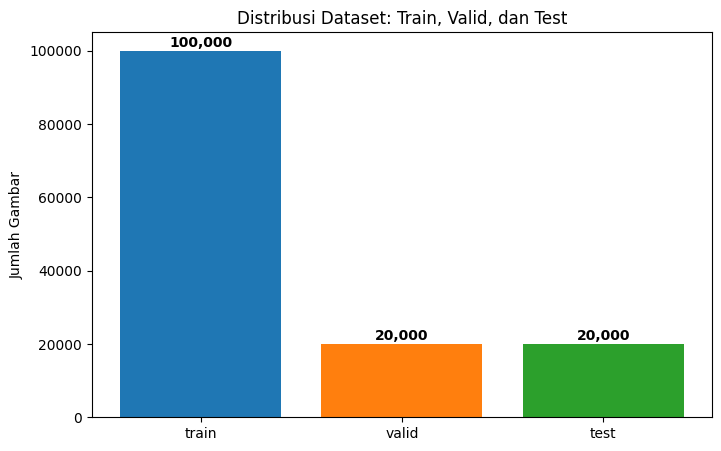

In [4]:
import os
import matplotlib.pyplot as plt

# 1. Sesuaikan path dengan struktur foldermu yang sebenarnya
base_dir = "./DATASET/real_vs_fake/real-vs-fake"

# Kategori folder dan kelas
splits = ['train', 'valid', 'test']
classes = ['real', 'fake']

print("--- Exploratory Data Analysis (EDA) ---")

# Siapkan tempat untuk menyimpan data grafik
plot_data = {'train': 0, 'valid': 0, 'test': 0}

# 2. Menghitung jumlah gambar di setiap folder
for split in splits:
    print(f"\n📊 Distribusi untuk {split.upper()}:")
    total_split = 0
    
    for cls in classes:
        # Menggabungkan path, contoh: ./DATASET/real_vs_fake/real-vs-fake/train/real
        path = os.path.join(base_dir, split, cls)
        
        try:
            count = len(os.listdir(path))
            print(f"  - {cls}: {count:,} gambar")
            total_split += count
        except FileNotFoundError:
            print(f"  - {cls}: ❌ Folder tidak ditemukan di {path}")
            
    plot_data[split] = total_split
    print(f"  Total {split}: {total_split:,} gambar")

# 3. Membuat Grafik untuk Laporan Skripsi
plt.figure(figsize=(8, 5))
plt.bar(plot_data.keys(), plot_data.values(), color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.title("Distribusi Dataset: Train, Valid, dan Test")
plt.ylabel("Jumlah Gambar")

# Menambahkan angka di atas bar
for i, v in enumerate(plot_data.values()):
    plt.text(i, v + 1000, f"{v:,}", ha='center', fontweight='bold')

plt.show()

In [1]:
import os
import hashlib
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

# 1. Tentukan Path Dataset
base_dir = "./DATASET/real_vs_fake/real-vs-fake"

print("--- Memulai Pengecekan Data Duplikat (MD5 Hashing) ---")

# 2. Kumpulkan semua jalur file gambar terlebih dahulu
all_files = []
for split in ['train', 'valid', 'test']:
    for cls in ['real', 'fake']:
        folder_path = os.path.join(base_dir, split, cls)
        if os.path.exists(folder_path):
            for file_name in os.listdir(folder_path):
                if file_name.endswith(('.jpg', '.jpeg', '.png')):
                    all_files.append(os.path.join(folder_path, file_name))

print(f"Total gambar yang akan dipindai: {len(all_files):,} file")

# 3. Proses mencari 'Sidik Jari' duplikat
hashes = {}
duplicates = []

for file_path in tqdm(all_files, desc="Scanning Images"):
    # Membaca file sebagai byte dan membuat hash MD5
    with open(file_path, 'rb') as f:
        file_hash = hashlib.md5(f.read()).hexdigest()
        
    if file_hash in hashes:
        # Jika hash sudah ada, berarti ini duplikat!
        duplicates.append((file_path, hashes[file_hash]))
    else:
        # Jika belum ada, simpan ke memori
        hashes[file_hash] = file_path

# 4. Laporan Hasil
print("\n--- LAPORAN HASIL PENGECEKAN ---")
if len(duplicates) == 0:
    print("✅ LUAR BIASA! Tidak ditemukan gambar duplikat sama sekali. Dataset kamu sangat bersih!")
else:
    print(f"⚠️ GAWAT! Ditemukan {len(duplicates):,} gambar duplikat!")
    print("Contoh file yang kembar:")
    # Tampilkan 5 contoh duplikat
    for i in range(min(5, len(duplicates))):
        print(f"  [Kembaran {i+1}]")
        print(f"  - File 1: {duplicates[i][0]}")
        print(f"  - File 2: {duplicates[i][1]}")

--- Memulai Pengecekan Data Duplikat (MD5 Hashing) ---
Total gambar yang akan dipindai: 140,000 file


Scanning Images:   0%|          | 0/140000 [00:00<?, ?it/s]


--- LAPORAN HASIL PENGECEKAN ---
✅ LUAR BIASA! Tidak ditemukan gambar duplikat sama sekali. Dataset kamu sangat bersih!


In [2]:
from PIL import Image
import os
from tqdm.notebook import tqdm

print("--- Memulai Pengecekan File Gambar Corrupt (Rusak) ---")

corrupted_files = []

# Menggunakan list 'all_files' dari kodingan MD5 sebelumnya
for file_path in tqdm(all_files, desc="Memeriksa Integritas Gambar"):
    try:
        # Mencoba membuka dan memverifikasi header file gambar
        img = Image.open(file_path)
        img.verify() 
    except (IOError, SyntaxError) as e:
        # Jika gagal dibuka, masukkan ke daftar hitam
        corrupted_files.append(file_path)

# Laporan Akhir
print("\n--- LAPORAN HASIL PENGECEKAN FILE RUSAK ---")
if len(corrupted_files) == 0:
    print("✅ AMAN SENTOSA! Tidak ada gambar yang rusak/corrupt. Data 100% siap training!")
else:
    print(f"⚠️ DITEMUKAN {len(corrupted_files)} GAMBAR RUSAK!")
    print("Contoh file rusak:")
    for f in corrupted_files[:5]:
        print(f" - {f}")
        
    # Otomatis menghapus file yang rusak (Opsional, buka hashtag di bawah jika ingin langsung hapus)
    # for f in corrupted_files:
    #     os.remove(f)
    # print("Semua file rusak telah dihapus dari folder!")

--- Memulai Pengecekan File Gambar Corrupt (Rusak) ---


Memeriksa Integritas Gambar:   0%|          | 0/140000 [00:00<?, ?it/s]


--- LAPORAN HASIL PENGECEKAN FILE RUSAK ---
✅ AMAN SENTOSA! Tidak ada gambar yang rusak/corrupt. Data 100% siap training!
